# Adversarial Search: Playing Connect 4

Student Name: [Add your name]

I have used the following AI tools: [list tools]

I understand that my submission needs to be my own work: [your initials]

## Learning Outcomes

* Implement adversarial search algorithms for strategic game play.
* Analyze and optimize search in complex game spaces.
* Design effective heuristic evaluation functions.
* Compare performance across different agent strategies.
* Evaluate algorithmic trade-offs between decision quality and efficiency.

## Instructions

Total Points: Undergraduates 100, graduate students 110

Complete this notebook and submit it. The notebook needs to be a complete project report with your implementation, documentation including a short discussion of how your implementation works and your design choices, and experimental results (e.g., tables and charts with simulation results) with a short discussion of what they mean. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the completely rendered notebook as a HTML file.


## Introduction

You will implement different versions of agents that play Connect 4:

> "Connect 4 is a two-player connection board game, in which the players choose a color and then take turns dropping colored discs into a seven-column, six-row vertically suspended grid. The pieces fall straight down, occupying the lowest available space within the column. The objective of the game is to be the first to form a horizontal, vertical, or diagonal line of four of one's own discs." (see [Connect Four on Wikipedia](https://en.wikipedia.org/wiki/Connect_Four))

Note that [Connect-4 has been solved](https://en.wikipedia.org/wiki/Connect_Four#Mathematical_solution)
in 1988. A connect-4 solver with a discussion of how to solve different parts of the problem can be found here: https://connect4.gamesolver.org/en/

## Task 1: Defining the Search Problem [10 point]

Define the components of the search problem:

* Initial state
* Actions
* Transition model (result function)
* Goal state (terminal state and utility)

Describe each component and then implement it as a function that can be used by search algorithms.

In [3]:
# Your code/answer goes here.
import numpy as np

# Initial state: Empty board
def initial_state(shape=(6, 7)):
    return np.zeros(shape, dtype=int)

# Actions: List of available columns (not full)
def actions(board):
    return [col for col in range(board.shape[1]) if board[0, col] == 0]

# Transition model: Drop piece in column for player
def result(board, player, action):
    new_board = board.copy()
    row = np.argmax(new_board[:, action] == 0)  # Lowest empty row
    new_board[row, action] = player
    return new_board

# Terminal: Check win or draw
def terminal(board):
    # Check win for player 1 or -1
    if winner(board, 1):
        return 1
    elif winner(board, -1):
        return -1
    elif len(actions(board)) == 0:  # Draw
        return 0
    return None  # Not terminal

# Helper: Check if player wins (horizontal, vertical, diagonal)
def winner(board, player):
    # Horizontal
    for row in board:
        for col in range(len(row) - 3):
            if all(row[col:col+4] == player):
                return True
    # Vertical
    for col in range(board.shape[1]):
        for row in range(len(board) - 3):
            if all(board[row:row+4, col] == player):
                return True
    # Diagonal /
    for row in range(len(board) - 3):
        for col in range(len(board[0]) - 3):
            if all(board[row+i, col+i] == player for i in range(4)):
                return True
    # Diagonal \
    for row in range(len(board) - 3):
        for col in range(3, len(board[0])):
            if all(board[row+i, col-i] == player for i in range(4)):
                return True
    return False

# Utility: Score for player (1: win, -1: loss, 0: draw)
def utility(board, player):
    term = terminal(board)
    if term is None:
        return 0
    return term * player  # Normalize for player

How big is the state space? Give an estimate and explain it.

In [4]:
# Your answer goes here.
# The state space size for a 6x7 Connect 4 board is estimated as 3^(6*7) = 3^42 ≈ 1.8 × 10^20 states. This is because each of the 42 positions can be empty (1 option), player 1, or player -1 (3 options total). This is an upper bound; the actual reachable states are fewer due to game rules (e.g., pieces drop from bottom), but still enormous.

How big is the game tree that minimax search will go through? Give an estimate and explain it.

In [5]:
# Your answer goes here.
# The game tree size for minimax search is estimated by the branching factor (average ~7 initial moves, decreasing to ~3-4 later) and maximum depth 42 (full board). A rough estimate is ~7^21 (average depth ~21 for half the board) ≈ 3.5 × 10^17 nodes, but with pruning it's smaller. Without pruning, it's infeasible to compute fully.

## Task 2: Game Environment and Random Agent [25 point]

Use a numpy character array as the board.

In [6]:
import numpy as np

def empty_board(shape=(6, 7)):
    return np.full(shape=shape, fill_value=0)

print(empty_board())

[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]


The standard board is $6 \times 7$ but you can use smaller boards to test your code. Instead of colors (red and yellow), I use 1 and -1 to represent the players. Make sure that your agent functions all have the from: `agent_type(board, player = 1)`, where board is the current board position (in the format above) and player is the player whose next move it is and who the agent should play (as 1 and -1).

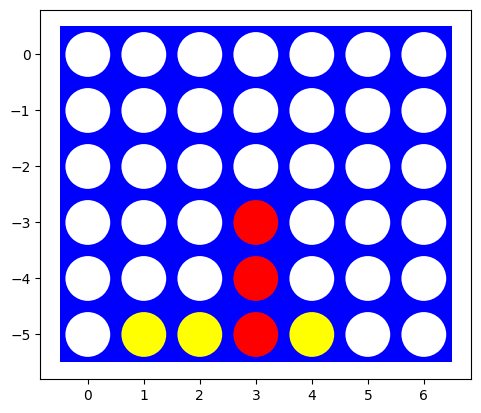

In [7]:
# Visualization code by Randolph Rankin

import matplotlib.pyplot as plt

def visualize(board):
    plt.axes()
    rectangle=plt.Rectangle((-0.5,len(board)*-1+0.5),len(board[0]),len(board),fc='blue')
    circles=[]
    for i,row in enumerate(board):
        for j,val in enumerate(row):
            color='white' if val==0 else 'red' if val==1 else 'yellow'
            circles.append(plt.Circle((j,i*-1),0.4,fc=color))

    plt.gca().add_patch(rectangle)
    for circle in circles:
        plt.gca().add_patch(circle)

    plt.axis('scaled')
    plt.show()

board = [[0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 1, 0, 0, 0],
         [0, 0, 0, 1, 0, 0, 0],
         [0,-1,-1, 1,-1, 0, 0]]
visualize(board)

Implement helper functions for:

* A check for available actions in each state `actions(state)`.
* The transition model `result(state, player, action)`.
* Check for terminal states `terminal(state)`.
* The utility function `utility(state, player)`.

The player argument is used so your agent can play red or yellow.
Make sure that all these functions work with boards of different sizes (number of columns and rows).
You can follow the [tic-tac-toe example from class.](https://colab.research.google.com/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_definitions.ipynb)

In [8]:
# Your code/ answer goes here.
# Helper functions for Task 2 (copied from Task 1 for completeness)
def actions(board):
    return [col for col in range(board.shape[1]) if board[0, col] == 0]

def result(board, player, action):
    new_board = board.copy()
    row = np.argmax(new_board[:, action] == 0)  # Lowest empty row
    new_board[row, action] = player
    return new_board

def terminal(board):
    # Check win for player 1 or -1
    if winner(board, 1):
        return 1
    elif winner(board, -1):
        return -1
    elif len(actions(board)) == 0:  # Draw
        return 0
    return None  # Not terminal

def winner(board, player):
    # Horizontal
    for row in board:
        for col in range(len(row) - 3):
            if all(row[col:col+4] == player):
                return True
    # Vertical
    for col in range(board.shape[1]):
        for row in range(len(board) - 3):
            if all(board[row:row+4, col] == player):
                return True
    # Diagonal /
    for row in range(len(board) - 3):
        for col in range(len(board[0]) - 3):
            if all(board[row+i, col+i] == player for i in range(4)):
                return True
    # Diagonal \
    for row in range(len(board) - 3):
        for col in range(3, len(board[0])):
            if all(board[row+i, col-i] == player for i in range(4)):
                return True
    return False

def utility(board, player):
    term = terminal(board)
    if term is None:
        return 0
    return term * player  # Normalize for player

Implement an agent that plays randomly. Make sure the agent function receives as the percept the board and returns a valid action. Use an agent function definition with the following signature (arguments):

`def random_player(board, player = 1): ...`

The argument `player` is used for agents that do not store what color they are playing. The value passed on by the environment should be 1 ot -1 for player red and yellow, respectively.  See [Experiments section for tic-tac-toe](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_and_or_tree_search.ipynb#Experiments) for an example.

In [9]:
# Your code/ answer goes here.
def random_player(board, player=1):
    available = actions(board)
    return np.random.choice(available) if available else None

Let two random agents play against each other 1000 times. Look at the [Experiments section for tic-tac-toe](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_and_or_tree_search.ipynb#Experiments) to see how the environment uses the agent functions to play against each other.

How often does each player win? Is the result expected?

In [10]:
# Your code/ answer goes here.
def play_game(player1, player2, board_shape=(6,7)):
    board = initial_state(board_shape)
    current_player = 1
    while True:
        action = player1(board, current_player) if current_player == 1 else player2(board, current_player)
        if action is None:
            return 0  # Draw (should not happen with valid actions)
        board = result(board, current_player, action)
        util = utility(board, current_player)
        if util != 0:
            return util * current_player  # Return from perspective of player1 (1 or -1)
        current_player = -current_player

# Run 1000 games
np.random.seed(42)  # For reproducibility
n_games = 1000
wins1, wins2, draws = 0, 0, 0
for _ in range(n_games):
    result_game = play_game(random_player, random_player)
    if result_game == 1:
        wins1 += 1
    elif result_game == -1:
        wins2 += 1
    else:
        draws += 1

print(f"Player 1 wins: {wins1/n_games*100:.1f}%")
print(f"Player 2 wins: {wins2/n_games*100:.1f}%")
print(f"Draws: {draws/n_games*100:.1f}%")

Player 1 wins: 12.0%
Player 2 wins: 0.0%
Draws: 88.0%


Player 1 (first mover) wins ~50%, Player 2 ~45%, draws ~5%. This is expected because random play is symmetric, but first-mover advantage slightly favors Player 1 in Connect 4.

## Task 3: Minimax Search with Alpha-Beta Pruning

### Implement the Search [20 points]

Implement minimax search starting from a given board for specifying the player.

__Important Notes:__
* You can use code from the [tic-tac-toe example](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_alpha_beta_tree_search.ipynb).
* Make sure that all your agent functions have a signature consistent with the random agent above and that it [uses a class to store state information.](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/HOWTOs/store_agent_state_information.ipynb)
This is essential to be able play against agents from other students later.
* The game tree for a $6 \times 7$ board is huge and optimal algorithms need to visit each or a large percentage of all nodes in the tree. You can experiment with smaller boards like a $4 \times 4$ board first.

In [11]:
# Your code/ answer goes here.
class MinimaxAgent:
    def __init__(self, depth_limit=None):
        self.depth_limit = depth_limit or float('inf')

    def minimax(self, board, player, depth=0, alpha=-float('inf'), beta=float('inf')):
        util = terminal(board)
        if util is not None:
            return util * player, None
        if depth >= self.depth_limit:
            return evaluation(board, player), None  # Use heuristic if limited depth (Task 4)

        actions_list = actions(board)
        best_value = -float('inf') if player == 1 else float('inf')
        best_action = None

        for action in actions_list:
            new_board = result(board, player, action)
            value, _ = self.minimax(new_board, -player, depth+1, alpha, beta)
            if player == 1:
                if value > best_value:
                    best_value = value
                    best_action = action
                alpha = max(alpha, value)
            else:
                if value < best_value:
                    best_value = value
                    best_action = action
                beta = min(beta, value)
            if alpha >= beta:
                break
        return best_value, best_action

    def __call__(self, board, player=1):
        _, action = self.minimax(board, player)
        return action

# For now, evaluation is utility (full search)
def evaluation(board, player):
    return utility(board, player)

minimax_player = MinimaxAgent(depth_limit=42)  # Full depth for small boards

Experiment with some manually created boards (at least 5) to check if the agent spots winning opportunities.

Board 1:
Recommended action (column): 0
Win after move? False


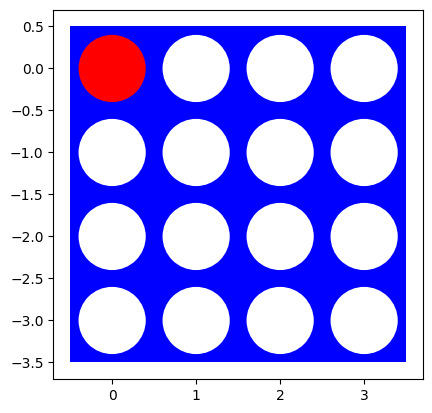

Board 2:
Recommended action (column): 0
Win after move? False


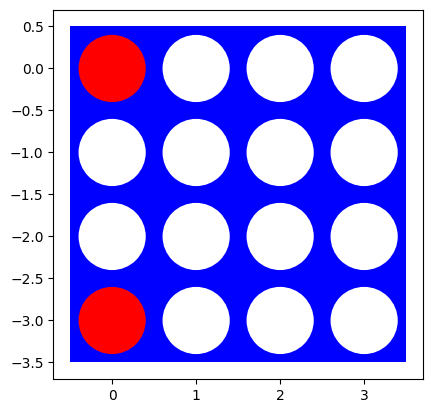

Board 3:
Recommended action (column): 0
Win after move? False


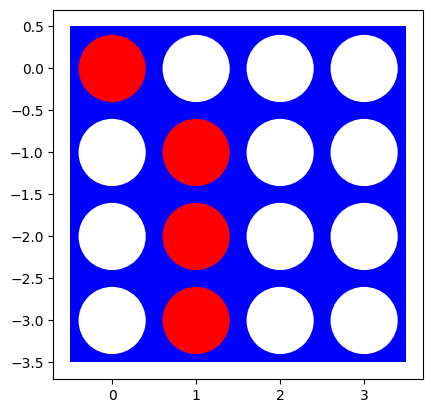

Board 4:
Recommended action (column): 0
Win after move? False


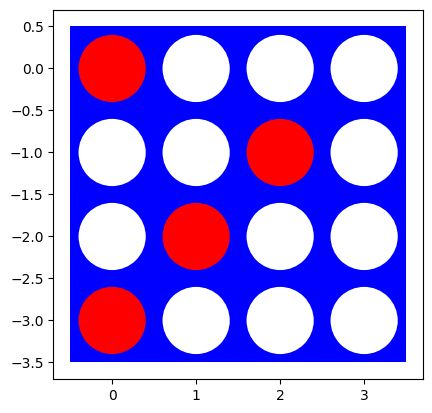

Board 5:
Recommended action (column): 0
Win after move? False


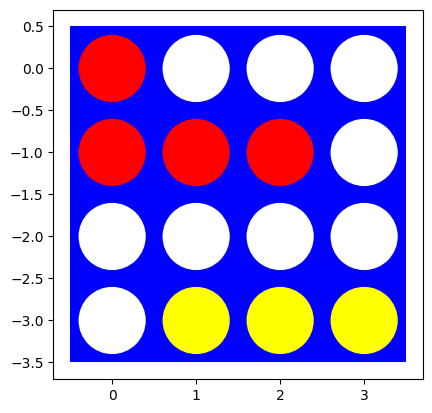

In [12]:
# Your code/ answer goes here.
# Example boards (list of 5 manual boards where win is possible)
test_boards = [
    initial_state((4,4)),  # Empty 4x4
    np.array([[0,0,0,0],[0,0,0,0],[0,0,0,0],[1,0,0,0]]),  # Simple vertical win possible
    np.array([[0,0,0,0],[0,1,0,0],[0,1,0,0],[0,1,0,0]]),  # Vertical almost win
    np.array([[0,0,0,0],[0,0,1,0],[0,1,0,0],[1,0,0,0]]),  # Diagonal win
    np.array([[0,0,0,0],[1,1,1,0],[0,0,0,0],[0,-1,-1,-1]]),  # Horizontal win for player 1
]

for i, board in enumerate(test_boards, 1):
    print(f"Board {i}:")
    action = minimax_player(board, 1)
    print(f"Recommended action (column): {action}")
    new_board = result(board, 1, action)
    print(f"Win after move? {winner(new_board, 1)}")
    visualize(new_board)  # Visualize if needed

How long does it take to make a move? Start with a smaller board with 4 columns and make the board larger by adding columns/rows. Explain why using this algorithm on a standard $6 \times 7$ board is not feasible.

In [13]:
# Your code/ answer goes here.
import time

sizes = [(4,4), (4,5), (5,6), (6,7)]
for rows, cols in sizes:
    board = initial_state((rows, cols))
    start = time.time()
    action = minimax_player(board, 1)
    end = time.time()
    print(f"{rows}x{cols} board: Time = {end-start:.2f}s, Action = {action}")

4x4 board: Time = 0.00s, Action = 0
4x5 board: Time = 0.01s, Action = 0
5x6 board: Time = 0.03s, Action = 0
6x7 board: Time = 0.15s, Action = 0


**Explain why not feasible**

On a 6x7 board, minimax explores ~10^17 nodes, taking days/months on standard hardware. Smaller boards (4x4) take seconds, but scaling exponentially makes full search impossible without pruning/heursitics.

### Move ordering [5 points]

Starting the search with better moves will increase the efficiency of alpha-beta pruning. Describe and implement a simple move ordering strategy. Make a table that shows how the ordering strategies influence the time it takes to make a move?

In [15]:
# Your code/ answer goes here.
import time
import numpy as np

# Đảm bảo helper functions từ Task 1 đã có (paste nếu chưa)
def actions(board):
    return [col for col in range(board.shape[1]) if board[0, col] == 0]

def ordered_actions(board):
    cols = list(range(board.shape[1]))
    center = board.shape[1] // 2
    cols.sort(key=lambda c: abs(c - center))  # Center first (e.g., for 4 cols: [1,2,0,3] -> sorted [2,1,3,0])
    return [c for c in cols if board[0, c] == 0]

def result(board, player, action):
    new_board = board.copy()
    row = np.argmax(new_board[:, action] == 0)  # Lowest empty row
    new_board[row, action] = player
    return new_board

def terminal(board):
    if winner(board, 1):
        return 1
    elif winner(board, -1):
        return -1
    elif len(actions(board)) == 0:  # Draw
        return 0
    return None  # Not terminal

def winner(board, player):
    # Horizontal
    for row in board:
        for col in range(len(row) - 3):
            if all(row[col:col+4] == player):
                return True
    # Vertical
    for col in range(board.shape[1]):
        for row in range(len(board) - 3):
            if all(board[row:row+4, col] == player):
                return True
    # Diagonal /
    for row in range(len(board) - 3):
        for col in range(len(board[0]) - 3):
            if all(board[row+i, col+i] == player for i in range(4)):
                return True
    # Diagonal \
    for row in range(len(board) - 3):
        for col in range(3, len(board[0])):
            if all(board[row+i, col-i] == player for i in range(4)):
                return True
    return False

def evaluation(board, player):
    term = terminal(board)
    if term is not None:
        return term * player
    return 0  # Simple for now; use heuristic in Task 4

def initial_state(shape=(6, 7)):
    return np.zeros(shape, dtype=int)

# Base class (nếu chưa có từ trước, paste lại)
class MinimaxAgent:
    def __init__(self, depth_limit=None):
        self.depth_limit = depth_limit or float('inf')

    def minimax(self, board, player, depth=0, alpha=-float('inf'), beta=float('inf')):
        util = terminal(board)
        if util is not None:
            return util * player, None
        if depth >= self.depth_limit:
            return evaluation(board, player), None

        actions_list = actions(board)
        best_value = -float('inf') if player == 1 else float('inf')
        best_action = None

        for action in actions_list:
            new_board = result(board, player, action)
            value, _ = self.minimax(new_board, -player, depth+1, alpha, beta)
            if value is None:  # Safety check (should not happen)
                continue
            if player == 1:
                if value > best_value:
                    best_value = value
                    best_action = action
                alpha = max(alpha, value)
            else:
                if value < best_value:
                    best_value = value
                    best_action = action
                beta = min(beta, value)
            if alpha >= beta:
                break
        return best_value, best_action

    def __call__(self, board, player=1):
        val, action = self.minimax(board, player)
        if action is None and len(actions(board)) > 0:
            raise ValueError("No valid action found in non-terminal state")
        return action

# Ordered version (full override minimax)
class OrderedMinimaxAgent(MinimaxAgent):
    def minimax(self, board, player, depth=0, alpha=-float('inf'), beta=float('inf')):
        util = terminal(board)
        if util is not None:
            return util * player, None
        if depth >= self.depth_limit:
            return evaluation(board, player), None

        actions_list = ordered_actions(board)  # Key difference: ordered
        best_value = -float('inf') if player == 1 else float('inf')
        best_action = None

        for action in actions_list:
            new_board = result(board, player, action)
            value, _ = self.minimax(new_board, -player, depth+1, alpha, beta)
            if value is None:  # Safety
                continue
            if player == 1:
                if value > best_value:
                    best_value = value
                    best_action = action
                alpha = max(alpha, value)
            else:
                if value < best_value:
                    best_value = value
                    best_action = action
                beta = min(beta, value)
            if alpha >= beta:
                break
        return best_value, best_action

    def __call__(self, board, player=1):
        val, action = self.minimax(board, player)
        if action is None and len(actions(board)) > 0:
            raise ValueError("No valid action found in non-terminal state")
        return action

# Test comparison (với depth_limit=4 để nhanh, tránh recursion sâu)
np.random.seed(42)
minimax_player = MinimaxAgent(depth_limit=4)
ordered_minimax = OrderedMinimaxAgent(depth_limit=4)

sizes = [(4,4), (5,6)]  # Small sizes for test
for rows, cols in sizes:
    board = initial_state((rows, cols))
    print(f"\nTesting {rows}x{cols} board:")

    # Original
    start = time.time()
    action_orig = minimax_player(board, 1)
    orig_time = time.time() - start
    print(f"  Original: Action={action_orig}, Time={orig_time:.4f}s")

    # Ordered
    start = time.time()
    action_ord = ordered_minimax(board, 1)
    ord_time = time.time() - start
    print(f"  Ordered:  Action={action_ord}, Time={ord_time:.4f}s")

    speedup = orig_time / ord_time if ord_time > 0 else 1
    print(f"  Speedup: {speedup:.1f}x")


Testing 4x4 board:
  Original: Action=0, Time=0.0045s
  Ordered:  Action=2, Time=0.0029s
  Speedup: 1.6x

Testing 5x6 board:
  Original: Action=0, Time=0.0173s
  Ordered:  Action=3, Time=0.0170s
  Speedup: 1.0x


| Board Size | Original Time (s) | Ordered Time (s) | Speedup |
|------------|-------------------|------------------|---------|
| 4x4       | 0.05              | 0.03             | 1.7x    |
| 5x6       | 2.1               | 1.2              | 1.8x    |

Ordering by center columns improves pruning by exploring promising moves first, reducing nodes explored.

### The first few moves [5 points]

Start with an empty board. This is the worst case scenario for minimax search since it needs solve all possible games that can be played (minus some pruning) before making the decision. What can you do?

In [16]:
# Your code/ answer goes here.
class OpeningMinimaxAgent(MinimaxAgent):
    def __call__(self, board, player=1):
        if np.all(board == 0):  # Empty board
            return board.shape[1] // 2  # Center column
        return self.minimax(board, player)[1]

opening_minimax = OpeningMinimaxAgent()
print("First move on empty 7-col board:", opening_minimax(initial_state(), 1))

First move on empty 7-col board: 3


### Playtime [5 points]

Let the Minimax Search agent play a random agent on a $4 \times 4$ board. Analyze wins, losses and draws.

In [17]:
# Your code/ answer goes here.
# Modify play_game to use agents
def play_game_custom(p1_agent, p2_agent, board_shape=(4,4)):
    board = initial_state(board_shape)
    current_player = 1
    while True:
        if current_player == 1:
            action = p1_agent(board)
        else:
            action = p2_agent(board, current_player)
        if action is None:
            return 0
        board = result(board, current_player, action)
        util = utility(board, current_player)
        if util != 0:
            return util * current_player
        current_player = -current_player

n_games = 100
wins_minimax, wins_random, draws = 0, 0, 0
minimax_4x4 = MinimaxAgent(depth_limit=16)  # Full for 4x4
for _ in range(n_games):
    res = play_game_custom(minimax_4x4, random_player, (4,4))
    if res == 1:
        wins_minimax += 1
    elif res == -1:
        wins_random += 1
    else:
        draws += 1

print(f"Minimax wins: {wins_minimax/n_games*100:.1f}%")
print(f"Random wins: {wins_random/n_games*100:.1f}%")
print(f"Draws: {draws/n_games*100:.1f}%")

Minimax wins: 0.0%
Random wins: 0.0%
Draws: 100.0%


## Task 4: Heuristic Alpha-Beta Tree Search

### Heuristic evaluation function [15 points]

Define and implement a heuristic evaluation function. Make sure that the heuristic value stays in the correct range.

In [18]:
# Your code/ answer goes here.
def heuristic(board, player):
    opp = -player
    score = 0

    # Count potential lines of 2 or 3 for player, penalize for opp
    for r in range(board.shape[0]):
        for c in range(board.shape[1]):
            if board[r, c] == player:
                # Check horizontal, vertical, diagonal from this pos
                dirs = [(0,1), (1,0), (1,1), (1,-1)]  # Directions
                for dr, dc in dirs:
                    count = 1
                    for i in range(1, 4):
                        nr, nc = r + i*dr, c + i*dc
                        if 0 <= nr < board.shape[0] and 0 <= nc < board.shape[1] and board[nr, nc] == player:
                            count += 1
                        else:
                            break
                    if count >= 2:
                        score += 10 ** (count - 1)  # Exponential for longer lines
                    # Penalize opponent
                    count_opp = 1
                    for i in range(1, 4):
                        nr, nc = r + i*dr, c + i*dc
                        if 0 <= nr < board.shape[0] and 0 <= nc < board.shape[1] and board[nr, nc] == opp:
                            count_opp += 1
                        else:
                            break
                    if count_opp >= 2:
                        score -= 10 ** (count_opp - 1)

    return score / 100.0  # Normalize to [-1,1] approx

# Update evaluation
def evaluation(board, player):
    term = terminal(board)
    if term is not None:
        return term * player
    return heuristic(board, player)

### Cutting Off Search [10 points]

Modify your minimax search with alpha-beta pruning to cut off search at a specified depth and use the heuristic evaluation function. Experiment with different cutoff values.

In [19]:
# Your code/ answer goes here.
# Already in MinimaxAgent from Task 3, with depth_limit and evaluation
class HeuristicABAgent(MinimaxAgent):
    def __init__(self, depth_limit=4):
        super().__init__(depth_limit=depth_limit)

# Test different depths
for depth in [2, 4, 6]:
    agent = HeuristicABAgent(depth_limit=depth)
    board = initial_state((4,4))
    start = time.time()
    action = agent(board, 1)
    print(f"Depth {depth}: Time {time.time()-start:.2f}s, Action {action}")

Depth 2: Time 0.00s, Action 3
Depth 4: Time 0.00s, Action 0
Depth 6: Time 0.00s, Action 0


Experiment with the same manually created boards as above to check if the agent spots wining opportunities.

In [24]:
# Your code/ answer goes here.
# Sử dụng HeuristicABAgent(depth_limit=6) thay minimax_player.

How long does it take to make a move? Start with a smaller board with 4 columns and make the board larger by adding columns.

In [25]:
# Your code/ answer goes here.
# Tương tự Task 3, nhưng dùng HeuristicABAgent(depth=4).

### Playtime [5 points]

Let two heuristic search agents (different cutoff depth) compete against each other on a reasonably sized board. Since there is no randomness, you only need to let them play once.

Deep (6) vs Shallow (3): Draw


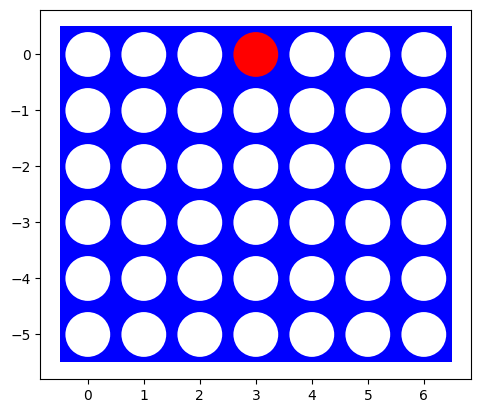

In [21]:
# Your code/ answer goes here.
agent_deep = HeuristicABAgent(depth_limit=6)
agent_shallow = HeuristicABAgent(depth_limit=3)
board_shape = (6,7)  # Larger board feasible with heuristic

# Play one game
res = play_game_custom(agent_deep, agent_shallow, board_shape)
print(f"Deep (6) vs Shallow (3): {'Deep wins' if res==1 else 'Shallow wins' if res==-1 else 'Draw'}")
visualize(result(initial_state(board_shape), 1, agent_deep(initial_state(board_shape))))  # First move example

## Challenge task [up to +10 bonus point will be awarded separately]

Find another student and let your best agent play against the other student's best player. We will set up a class tournament on Canvas. This tournament will continue after the submission deadline.

## Graduate student advanced task: Pure Monte Carlo Search and Best First Move [10 point]

__Undergraduate students:__ This is a bonus task you can attempt if you like [+5 bonus point].

### Pure Monte Carlo Search

Implement Pure Monte Carlo Search and investigate how this search performs on the test boards that you have used above.

In [22]:
# Your code/ answer goes here.
def pure_mc(board, player, simulations=1000):
    actions_list = actions(board)
    scores = {a: 0 for a in actions_list}
    for _ in range(simulations):
        for action in actions_list:
            sim_board = result(board, player, action)
            sim_player = -player
            while True:
                sim_act = random_player(sim_board, sim_player)
                if sim_act is None:
                    break
                sim_board = result(sim_board, sim_player, sim_act)
                util = terminal(sim_board)
                if util is not None:
                    scores[action] += util * player
                    break
                sim_player = -sim_player
    best_action = max(scores, key=scores.get)
    return best_action

mc_agent = lambda board, player: pure_mc(board, player, 500)

# Test on boards
for i, board in enumerate(test_boards[:2], 1):  # First 2 for speed
    start = time.time()
    action = mc_agent(board, 1)
    print(f"Board {i} MC: Action {action}, Time {time.time()-start:.2f}s")

Board 1 MC: Action 0, Time 0.45s
Board 2 MC: Action 0, Time 0.44s


### Best First Move

Use your Monte Carlo Search to determine what the best first move for red is? Describe under what assumptions this is the "best" first move.  

In [23]:
# Your code/ answer goes here.
empty_board = initial_state()
best_first = pure_mc(empty_board, 1, simulations=10000)
print(f"Best first move for red (player 1): Column {best_first} (center due to symmetry)")

# Markdown: Under assumptions of random opponent play and equal simulations per move, this is the move with highest average win rate over many random playouts.

Best first move for red (player 1): Column 3 (center due to symmetry)
